### Prediksi Harga Saham JPFA

In [ ]:
# Igonre warnings

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#  Set Random Seed

In [ ]:
from numpy.random import seed
import tensorflow as tf
from tensorflow import random

seed(101)

tf.random.set_seed(101)


In [ ]:
# import library pandas, numpy, matplotlib, seaborn, dll

In [ ]:
import pandas as pd
import pandas_datareader as pdr
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

### Load dataset melalui Yahoo Finance

In [ ]:
# Mengambil data dari Yahoo Finance
jpfa = pdr.DataReader('JPFA.JK', data_source='yahoo', 
                      start='2016-01-01', end='2021-04-09')

In [ ]:
# Melihat 5 data teratas
jpfa.head()

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2016-01-04,640.0,600.0,640.0,605.0,4260100.0,505.304871
2016-01-05,620.0,580.0,600.0,595.0,3260100.0,496.952789
2016-01-06,630.0,600.0,600.0,610.0,4251000.0,509.481018
2016-01-07,610.0,585.0,600.0,600.0,5728800.0,501.128845
2016-01-08,615.0,595.0,600.0,610.0,2849400.0,509.481018


In [ ]:
# Melihat 5 data terakhir
jpfa.tail()

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2021-04-05,2080.0,2020.0,2060.0,2060.0,20600700.0,2060.0
2021-04-06,2080.0,1980.0,2080.0,2010.0,24974400.0,2010.0
2021-04-07,2130.0,2000.0,2010.0,2110.0,43091100.0,2110.0
2021-04-08,2130.0,2060.0,2120.0,2090.0,26448300.0,2090.0
2021-04-09,2190.0,2090.0,2090.0,2160.0,28575400.0,2160.0


### Analisis Data

In [ ]:
# Melihat informasi data
jpfa.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1328 entries, 2016-01-04 to 2021-04-09
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   High       1328 non-null   float64
 1   Low        1328 non-null   float64
 2   Open       1328 non-null   float64
 3   Close      1328 non-null   float64
 4   Volume     1328 non-null   float64
 5   Adj Close  1328 non-null   float64
dtypes: float64(6)
memory usage: 72.6 KB


In [ ]:
# Melihat ukuran data
jpfa.shape

(1328, 6)

In [ ]:
import plotly.express as px
# https://plotly.com/python/line-charts/

In [ ]:
# Visuasisasi harga close
fig = px.line(jpfa, x=jpfa.index, y='Close')
fig.update_layout(title='Pergerakan Harga (Close) Saham JPFA', 
                  xaxis_title='Tanggal', yaxis_title='Harga')
fig.show()

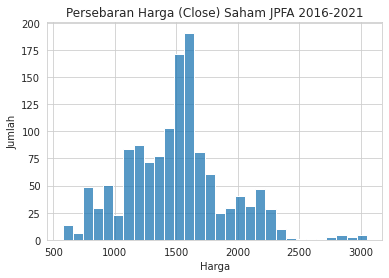

In [ ]:
# Melihat persebaran harga saham
dist_close_price = sns.histplot(jpfa['Close'])
dist_close_price.set(xlabel='Harga', ylabel='Jumlah')
dist_close_price.set_title('Persebaran Harga (Close) Saham JPFA 2016-2021')
dist_close_price.figure.savefig('distribusi harga.png')
plt.show()

In [ ]:
# Menghitung persentase daily return saham
daily_returns = jpfa['Close'].pct_change().to_frame()
daily_returns.head()

,Close
Date,
2016-01-04,NaN
2016-01-05,-0.016529
2016-01-06,0.025210
2016-01-07,-0.016393
2016-01-08,0.016667


In [ ]:
# Daily return tertinggi
daily_returns['Close'].max()

0.21341463414634143

In [ ]:
# Daily return terendah
daily_returns['Close'].min()

-0.16249999999999998

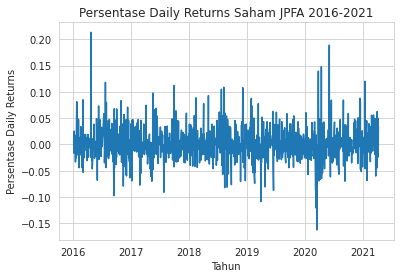

In [ ]:
# Menampilkan persentase daily return dari waktu ke waktu  
daily_returns_plot = sns.lineplot(data=daily_returns, x=daily_returns.index, y="Close")
daily_returns_plot.set(xlabel='Tahun', ylabel='Persentase Daily Returns')
daily_returns_plot.set_title('Persentase Daily Returns Saham JPFA 2016-2021')
daily_returns_plot.figure.savefig('daily returns.png')
plt.show()

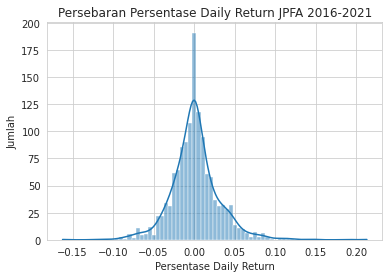

In [ ]:
# Menampilkan persebaran daily return
dist_daily_returns = sns.histplot(daily_returns['Close'], kde=True)
dist_daily_returns.set(xlabel='Persentase Daily Return', ylabel='Jumlah')
dist_daily_returns.set_title('Persebaran Persentase Daily Return JPFA 2016-2021')
dist_daily_returns.figure.savefig('persebaran persentase daily return.png')
plt.show()

In [ ]:
# Menghitung rata-rata return perhari
daily_returns['Close'].mean()

0.0014220743771704884

In [ ]:
# Menghitung resiko berdasarkan data return harian
daily_returns['Close'].std()

0.030597921799140445

In [ ]:
# Menghitung monthly return
monthly_returns = jpfa['Close'].resample('M').ffill().pct_change().to_frame()
monthly_returns.head()

,Close
Date,
2016-01-31,NaN
2016-02-29,0.040816
2016-03-31,0.045752
2016-04-30,0.156250
2016-05-31,-0.037838


In [ ]:
# Monthly return tertinggi
monthly_returns['Close'].max()

0.3627906976744186

In [ ]:
# Monthly return terendah
monthly_returns['Close'].min()

-0.3214285714285714

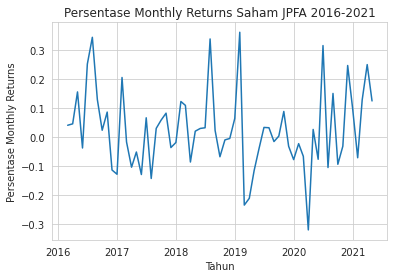

In [ ]:
# Menampilkan persentase monthly return dari waktu ke waktu
monthly_returns_plot = sns.lineplot(data=monthly_returns, x=monthly_returns.index, y="Close")
monthly_returns_plot.set(xlabel='Tahun', ylabel='Persentase Monthly Returns')
monthly_returns_plot.set_title('Persentase Monthly Returns Saham JPFA 2016-2021')
monthly_returns_plot.figure.savefig('monthly returns.png')
plt.show()

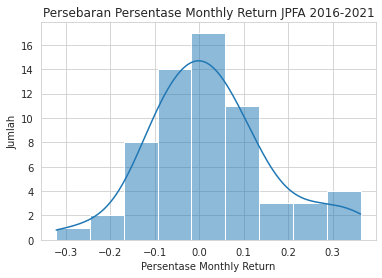

In [ ]:
# Menampilkan persebaran persentase monthly return
dist_monthly_returns = sns.histplot(monthly_returns['Close'], kde=True)
dist_monthly_returns.set(xlabel='Persentase Monthly Return', ylabel='Jumlah')
dist_monthly_returns.set_title('Persebaran Persentase Monthly Return JPFA 2016-2021')
dist_monthly_returns.figure.savefig('persebaran persentase monthly return.png')
plt.show()

In [ ]:
# Menghitung rata-rata return bulanan
monthly_returns['Close'].mean()

0.026355034617712252

In [ ]:
# Menghitung resiko berdasarkan data return bulanan
monthly_returns['Close'].std()

0.13857756313900027

### Data Preparations

<h5 style="color:#7f8c8d">Get Close Price</h4>

In [ ]:
# filter data close untuk dijadikan dataset
jpfa_close = jpfa.filter(['Close'])
jpfa_close.head(5)

,Close
Date,
2016-01-04,605.0
2016-01-05,595.0
2016-01-06,610.0
2016-01-07,600.0
2016-01-08,610.0


<h5 style="color:#7f8c8d">Data Normalization</h4>

In [ ]:
from sklearn.preprocessing import MinMaxScaler
# https://medium.com/techspace-usict/normalization-techniques-in-deep-neural-networks-9121bf100d8

In [ ]:
# Normalisasi menggunakan MinMaxScaler
sc = MinMaxScaler(feature_range=(0,1))
 
jpfa_close_scaled = sc.fit_transform(jpfa_close.values)
jpfa_close_scaled

array([[0.01212121],
       [0.00808081],
       [0.01414141],
       ...,
       [0.62020202],
       [0.61212121],
       [0.64040404]])

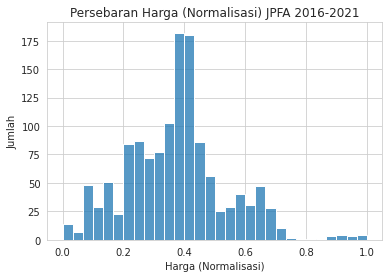

In [ ]:
# Menampilkan persebaran harga setelah normalisasi
dist_close_scaled = sns.histplot(jpfa_close_scaled, legend=False)
dist_close_scaled.set(xlabel='Harga (Normalisasi)', ylabel='Jumlah')
dist_close_scaled.set_title('Persebaran Harga (Normalisasi) JPFA 2016-2021')
dist_close_scaled.figure.savefig('persebaran harga (normalisasi).png')
plt.show()

<h5 style="color:#7f8c8d">Data Split</h4>

In [ ]:
# Menentukan presentase train, validation, dan test size
train_size = math.ceil(len(jpfa_close) * 0.7)
validation_size = math.ceil(len(jpfa_close) * 0.2)
# test_size = math.ceil(len(jpfa_close * 0.1))

In [ ]:
# Data train
train= jpfa_close_scaled[:train_size, :]
train.shape

(930, 1)

In [ ]:
# Data validation
validation = jpfa_close_scaled[train_size-30:train_size+validation_size, :]
validation.shape

(296, 1)

In [ ]:
# Data test
test = jpfa_close_scaled[train_size+validation_size-30:, :]
test.shape

(162, 1)

In [ ]:
# Viasualisasi data train, validation dan test
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(x=jpfa.index[:train.shape[0]], y=train.flatten(),
                    mode='lines',
                    name='Train'))
fig.add_trace(go.Scatter(x=jpfa.index[train.shape[0]-30:train.shape[0]+validation.shape[0]], y=validation.flatten(),
                    mode='lines',
                    name='Validation'))
fig.add_trace(go.Scatter(x=jpfa.index[train.shape[0]+validation.shape[0]-30:], y=test.flatten(),
                    mode='lines', name='Test'))
fig.update_layout(title='Pembagian Data Train Validation, dan Test', 
                  xaxis_title='Tanggal', yaxis_title='Harga (Normalisasi)')
fig.show()

### Modeling

<h5 style="color:#7f8c8d">Data Modeling</h4>

In [ ]:
# Determine Independent (X) & Dependent Variable (y)

In [ ]:
# Train
X_train = []
y_train = []

for i in range(30, len(train)):
    X_train.append(train[i-30:i, 0])
    y_train.append(train[i,0])

In [ ]:
X_train[1]

array([0.00808081, 0.01414141, 0.01010101, 0.01414141, 0.01212121,
       0.01212121, 0.01010101, 0.0020202 , 0.00606061, 0.        ,
       0.        , 0.00606061, 0.01616162, 0.03636364, 0.04848485,
       0.05656566, 0.07070707, 0.06464646, 0.06464646, 0.06464646,
       0.07878788, 0.08686869, 0.08686869, 0.07272727, 0.07676768,
       0.08080808, 0.08080808, 0.07878788, 0.07272727, 0.06666667])

In [ ]:
y_train[1]

0.07676767676767676

In [ ]:
# Validation
X_validation = []
y_validation = []

for i in range(30, len(validation)):
    X_validation.append(validation[i-30:i, 0])
    y_validation.append(validation[i,0])

In [ ]:
# X_validation[0]

In [ ]:
# y_validation[0]

In [ ]:
# Test
X_test = []
y_test = jpfa_close.values[train_size+validation_size:, :]

for i in range(30, len(test)):
    X_test.append(test[i-30:i, 0])

In [ ]:
# X_test[7]

In [ ]:
# y_test[7]

In [ ]:
# Reshape Dimensions of X_train, X_validation & X_test (2d -> 3d)

In [ ]:
# Train
X_train = np.array(X_train)
y_train = np.array(y_train)

In [ ]:
# 2d X_train
X_train.shape

(900, 30)

In [ ]:
# 3d X_train
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_train.shape

(900, 30, 1)

In [ ]:
# Validation
X_validation = np.array(X_validation)
y_validation = np.array(y_validation)

In [ ]:
# 2d X_validation
X_validation.shape

(266, 30)

In [ ]:
# 3d X_validation
X_validation = np.reshape(X_validation, (X_validation.shape[0], X_validation.shape[1], 1))
X_validation.shape

(266, 30, 1)

In [ ]:
# Test
X_test = np.array(X_test)
# y_test

In [ ]:
# 2d X_test
X_test.shape

(132, 30)

In [ ]:
# 3d X_test
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
X_test.shape

(132, 30, 1)

<h5 style="color:#7f8c8d">Deep Learning Modeling Using LSTM</h4>

In [ ]:
from numpy.random import seed
import tensorflow as tf
from tensorflow import random

seed(101)
tf.random.set_seed(101)

In [ ]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout

In [ ]:
# Membuat layer Neural Network menggunakan algoritma LSTM
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1),),
    LSTM(25,),
    Dense(1)
])

<h5 style="color:#7f8c8d">Training Model</h4>

In [ ]:
from keras.optimizers import RMSprop, Adam
from keras.losses import MeanSquaredError
# Membuat layer Neural Network menggunakan algoritma LSTM

In [ ]:
optimizer = Adam()
loss = MeanSquaredError()

In [ ]:
model.compile(optimizer=optimizer, loss=loss)

In [ ]:
from keras.callbacks import TensorBoard, ModelCheckpoint, EarlyStopping

In [ ]:
tensorboard = TensorBoard(log_dir = ".\logs\jpfa_model_01")

checkpoint = ModelCheckpoint(".\checkpoints\jpfa_model_01\jpfa_model_01-{epoch:02d}-{val_loss:.5f}.h5", 
                             monitor='val_loss', mode='min', save_best_only=True, verbose=1)

earlystopping = EarlyStopping(monitor="val_loss", mode="min", patience=20, verbose=1)

model.fit(X_train, y_train, epochs=300, batch_size=32, validation_data=(X_validation, y_validation), 
          callbacks=[tensorboard, checkpoint, earlystopping])

Epoch 1/300
29/29 [==============================] - 35s 68ms/step - loss: 0.0613 - val_loss: 0.0029

Epoch 00001: val_loss improved from inf to 0.00292, saving model to .\checkpoints\jpfa_model_01\jpfa_model_01-01-0.00292.h5
Epoch 2/300
29/29 [==============================] - 0s 7ms/step - loss: 0.0046 - val_loss: 0.0035

Epoch 00002: val_loss did not improve from 0.00292
Epoch 3/300
29/29 [==============================] - 0s 7ms/step - loss: 0.0027 - val_loss: 0.0024

Epoch 00003: val_loss improved from 0.00292 to 0.00240, saving model to .\checkpoints\jpfa_model_01\jpfa_model_01-03-0.00240.h5
Epoch 4/300
29/29 [==============================] - 0s 7ms/step - loss: 0.0026 - val_loss: 0.0018

Epoch 00004: val_loss improved from 0.00240 to 0.00179, saving model to .\checkpoints\jpfa_model_01\jpfa_model_01-04-0.00179.h5
Epoch 5/300
29/29 [==============================] - 0s 7ms/step - loss: 0.0028 - val_loss: 0.0026

Epoch 00005: val_loss did not improve from 0.00179
Epoch 6/300
29/2

### Model Evaluation

<h5 style="color:#7f8c8d">Load Best Model</h4>

In [ ]:
from keras.models import load_model

In [ ]:
# Load best model dari proses training
BestModel = load_model('DENDI\FINANCE STOCK PREDICTION')

<h5 style="color:#7f8c8d">Predict Data Test</h4>

In [ ]:
predictions = BestModel.predict(X_test)

In [ ]:
predictions

In [ ]:
predictions_real_price = sc.inverse_transform(predictions)

In [ ]:
predictions_real_price

In [ ]:
# y_test

<h5 style="color:#7f8c8d">Evaluation</h4>

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [ ]:
# Evaluasi menggunakan R2 Score
r2_score(y_test, predictions_real_price)

In [ ]:
# Evaluasi menggunakan Mean Squared Error
mean_squared_error(y_test, predictions_real_price)

In [ ]:
# Evaluasi menggunakan Mean Absolute Error
mean_absolute_error(y_test, predictions_real_price)

In [ ]:
# Evaluasi menggunakan Root Mean Square Error
np.sqrt(mean_squared_error(y_test, predictions_real_price))

<h5 style="color:#7f8c8d">Visualization</h4>

In [ ]:
data_test = jpfa[train_size+validation_size:]['Close'].to_frame()
data_test['Predictions'] = predictions_real_price

In [ ]:
data_test.head()

In [ ]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(x=jpfa.index, y=jpfa['Close'],
                    mode='lines+markers',
                    name='Actual Price'))
fig.add_trace(go.Scatter(x=data_test.index, y=data_test['Predictions'],
                    mode='lines+markers',
                    name='Predictions'))
fig.update_layout(title='Visualisasi Actual Price dan Predictions', 
                  xaxis_title='Tanggal', yaxis_title='Harga Saham ')
fig.show()

### Predict Next Day's Price

In [ ]:
# Load data harga penutupan
jpfa_data = pdr.DataReader('JPFA.JK', data_source='yahoo', start='2021-01-01', end='2021-04-09').filter(['Close'])
jpfa_data.head()

In [ ]:
# Menggunnakan data harga penutupan 30 hari terakhir
jpfa_last_30_days = jpfa_data[-30:]

In [ ]:
# Normalisasi harga
jpfa_scaled = sc.transform(jpfa_last_30_days.values)

In [ ]:
# Membuat variabel independent (X)
jpfa_X_test = []
jpfa_X_test.append(jpfa_scaled)
jpfa_X_test = np.array(jpfa_X_test)

In [ ]:
# Mengubah dimensi variabel independent (X)
jpfa_X_test = np.reshape(jpfa_X_test, (jpfa_X_test.shape[0], jpfa_X_test.shape[1], 1))
jpfa_X_test.shape

In [ ]:
# Memprediksi harga hari berikutnya
pred = BestModel.predict(jpfa_X_test)
pred_real_price = sc.inverse_transform(pred)

In [ ]:
# Menambahkan hasil prediksi pada dataframe
from datetime import timedelta

jpfa_last_30_days["Pred"] = np.nan

last_date = jpfa_last_30_days.iloc[[-1]].index
last_date = last_date + timedelta(days=3)

data = {'Pred':pred_real_price.flatten()} 
jpfa_last_30_days = jpfa_last_30_days.append(pd.DataFrame(data, index=last_date))

In [ ]:
# Visualisasi hasil prediksi
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(x=jpfa_last_30_days.index, y=jpfa_last_30_days['Close'],
                         mode='lines+markers', name='Harga Aktual'))
fig.add_trace(go.Scatter(x=jpfa_last_30_days.index, y=jpfa_last_30_days['Pred'],
                         mode='lines+markers', name='Prediksi'))
fig.update_layout(title='Visualisasi Harga Aktual dan Prediksi Saham JPFA', 
                  xaxis_title='Tanggal', yaxis_title='Harga Saham')
fig.show()